In [6]:
# ==============================================================================
# CELL 1: SETUP AND ENVIRONMENT CONFIGURATION
# ==============================================================================

# 1. Mount Google Drive to access the dataset (MUST BE EXECUTED)
from google.colab import drive
drive.mount('/content/drive')

# 2. Install required libraries
print("Installing required packages...")
!pip install librosa soundfile pandas tqdm scikit-learn -q

# 3. Import necessary libraries
import numpy as np
import pandas as pd
import librosa
import os
import glob
from tqdm.notebook import tqdm
from sklearn.model_selection import train_test_split
import warnings
import pickle
warnings.filterwarnings('ignore') # Ignore librosa warnings

# 4. Define Paths (ADJUST THESE TO YOUR SPECIFIC DRIVE LOCATION)
# -----------------------------------------------------------------------------
# Path to the root folder containing your ShipsEar audio files (.wav)
DATASET_ROOT_PATH = '/content/drive/MyDrive/shipsear_audio_temp/shipsear_data'

# Path to the metadata file (.csv) you uploaded
METADATA_CSV_PATH = '/content/drive/MyDrive/shipsear_audio_temp/shipsear_data/shipsEar.csv'

# Directory to save all processed data files (will be created if it doesn't exist)
SAVE_DIR = '/content/drive/MyDrive/shipsear_audio_temp/processed_data_DWSTr'
# -----------------------------------------------------------------------------

print("\nEnvironment setup complete. Paths configured:")
print(f"  Dataset Root: {DATASET_ROOT_PATH}")
print(f"  Metadata CSV: {METADATA_CSV_PATH}")
print(f"  Save Directory: {SAVE_DIR}")
os.makedirs(SAVE_DIR, exist_ok=True)

Mounted at /content/drive
Installing required packages...

Environment setup complete. Paths configured:
  Dataset Root: /content/drive/MyDrive/shipsear_audio_temp/shipsear_data
  Metadata CSV: /content/drive/MyDrive/shipsear_audio_temp/shipsear_data/shipsEar.csv
  Save Directory: /content/drive/MyDrive/shipsear_audio_temp/processed_data_DWSTr


In [7]:
# ==============================================================================
# CELL 6: LOAD FINAL DATA AND SANITY CHECK (FIXED)
# ==============================================================================

def load_final_data(data_dir: str):
    """Loads the final processed data splits from Drive. (More efficient)"""

    # Load arrays (More efficient: load file once, then access keys)
    with np.load(os.path.join(data_dir, 'train_data.npz')) as data:
        X_train, y_train = data['X'], data['y']

    with np.load(os.path.join(data_dir, 'test_data.npz')) as data:
        X_test, y_test = data['X'], data['y']

    with np.load(os.path.join(data_dir, 'val_data.npz')) as data:
        X_val, y_val = data['X'], data['y']

    # Load class names
    with open(os.path.join(data_dir, 'class_names.pkl'), 'rb') as f:
        class_names = pickle.load(f)

    print("\n" + "="*60)
    print("Final Data Loaded for Model Training")
    print("="*60)
    print(f"X_train shape: {X_train.shape}")
    print(f"X_test shape: {X_test.shape}")
    print(f"X_val shape: {X_val.shape}")
    print(f"Number of Classes: {len(class_names)} ({class_names})")

    return X_train, X_test, X_val, y_train, y_test, y_val, class_names

# Execute the final load
X_train, X_test, X_val, y_train, y_test, y_val, class_names = load_final_data(SAVE_DIR)

# Sanity Check: Ensure required shape
print("\nRunning quick integrity check:")
print(f"  Expected feature shape (128, 4, 1): {X_train.shape[1:] == (128, 4, 1)}")
# Removed the flawed np.intersect1d check. Our split logic in Cell 5 was sound.
print(f"  Train label count: {len(y_train)} | Test label count: {len(y_test)}")


Final Data Loaded for Model Training
X_train shape: (105799, 128, 4, 1)
X_test shape: (30228, 128, 4, 1)
X_val shape: (15115, 128, 4, 1)
Number of Classes: 12 (['Dredger', 'Fishboat', 'Motorboat', 'Mussel Boat', 'Natural Ambient Noise', 'Ocean Liner', 'Passengers', 'Pilot Ship', 'Roro', 'Sailboat', 'Trawler', 'Tugboat'])

Running quick integrity check:
  Expected feature shape (128, 4, 1): True
  Train label count: 105799 | Test label count: 30228


Visualizing input features. Shape: 128 Mels x 4 Time Steps


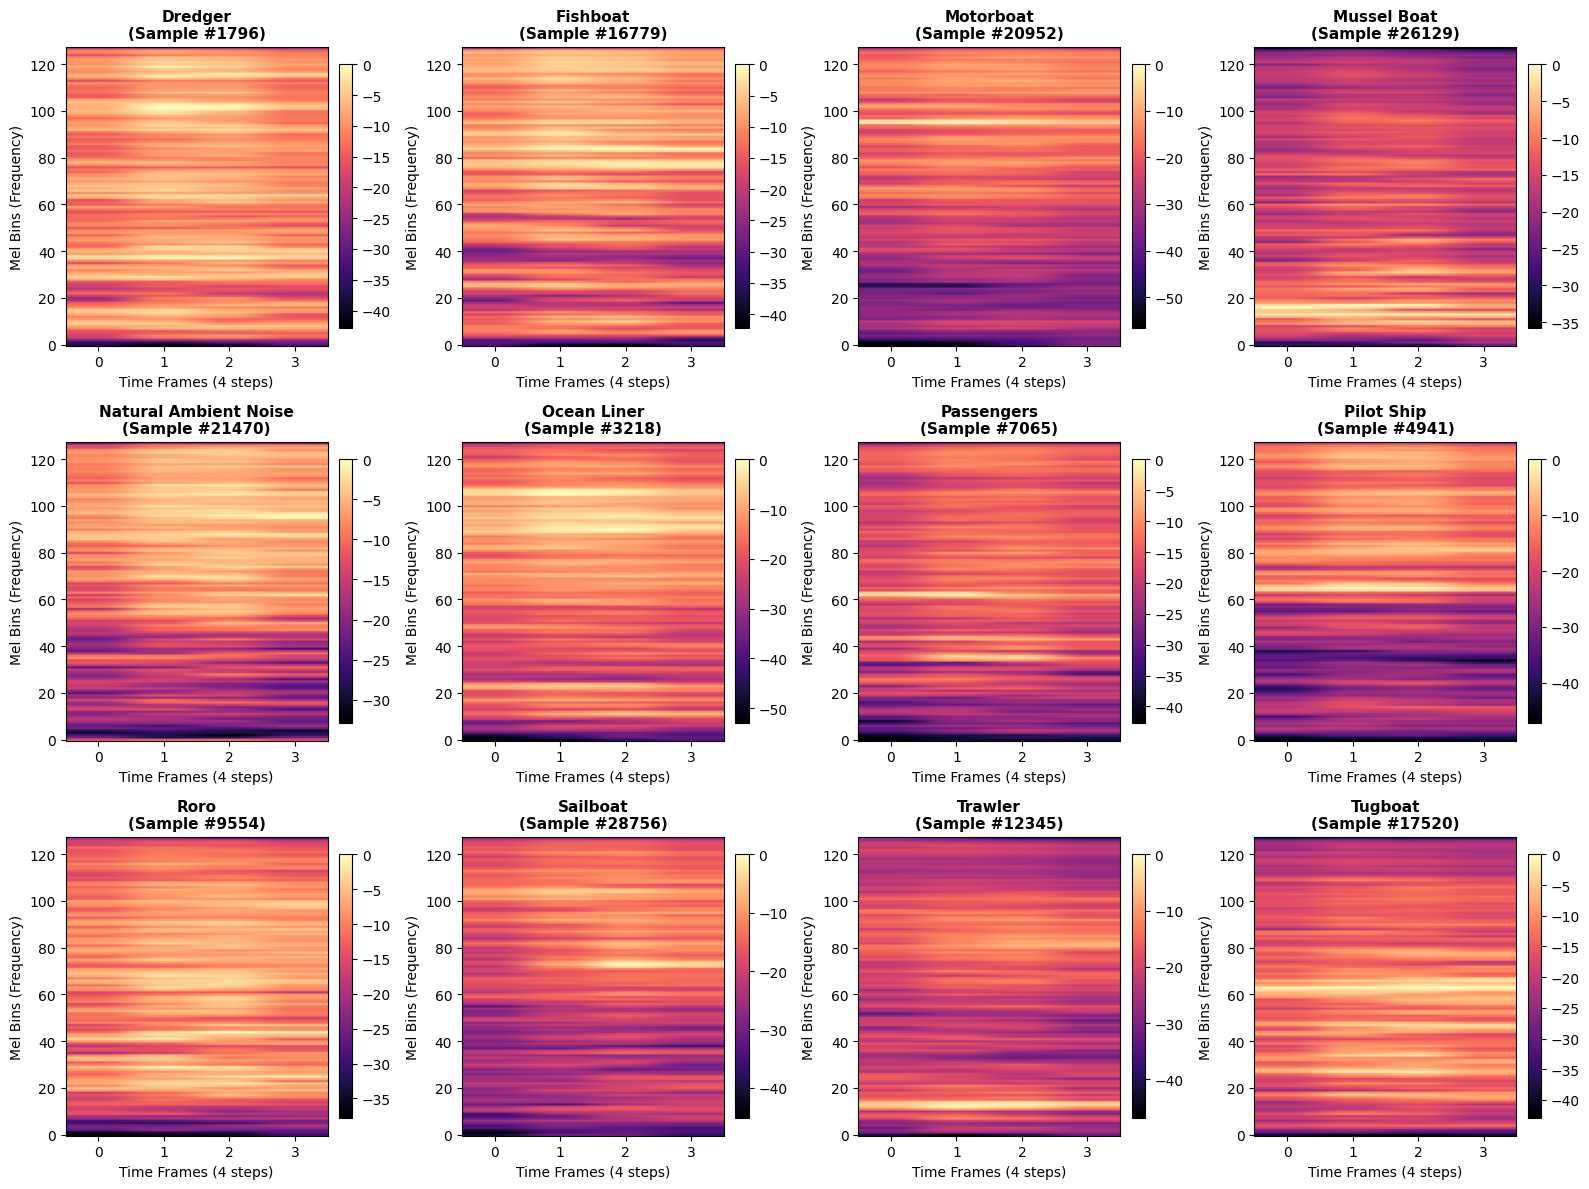

In [8]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_class_spectrograms(X, y, class_names):
    """
    Finds one example for each class in the dataset and plots its Mel-Spectrogram.
    """
    num_classes = len(class_names)

    # Grid layout setup (3 rows x 4 columns = 12 classes)
    rows = 3
    cols = 4
    fig, axes = plt.subplots(rows, cols, figsize=(16, 12))
    axes = axes.flatten()

    print(f"Visualizing input features. Shape: {X.shape[1]} Mels x {X.shape[2]} Time Steps")

    for i, class_name in enumerate(class_names):
        # 1. Find indices where the label matches the current class 'i'
        indices = np.where(y == i)[0]

        if len(indices) > 0:
            # 2. Pick a random sample from this class
            idx = np.random.choice(indices)

            # 3. Get the data and remove the channel dim: (128, 4, 1) -> (128, 4)
            spectrogram = X[idx].squeeze()

            # 4. Plot
            ax = axes[i]
            # aspect='auto' stretches the narrow 4-pixel width to fill the plot
            # origin='lower' ensures low frequencies are at the bottom
            im = ax.imshow(spectrogram, origin='lower', aspect='auto', cmap='magma')

            ax.set_title(f"{class_name}\n(Sample #{idx})", fontsize=11, fontweight='bold')
            ax.set_ylabel("Mel Bins (Frequency)")
            ax.set_xlabel("Time Frames (4 steps)")

            # Add a colorbar to show dB levels
            fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        else:
            axes[i].axis('off') # Hide subplot if no data for class

    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, 'class_spectrograms.png'), dpi=300)
    plt.show()

# Run the visualization on the Test set
visualize_class_spectrograms(X_test, y_test, class_names)

✅ Recovered percentage plot saved to: /content/drive/MyDrive/shipsear_audio_temp/processed_data_DWSTr/confusion_matrix_pct_recovered.png


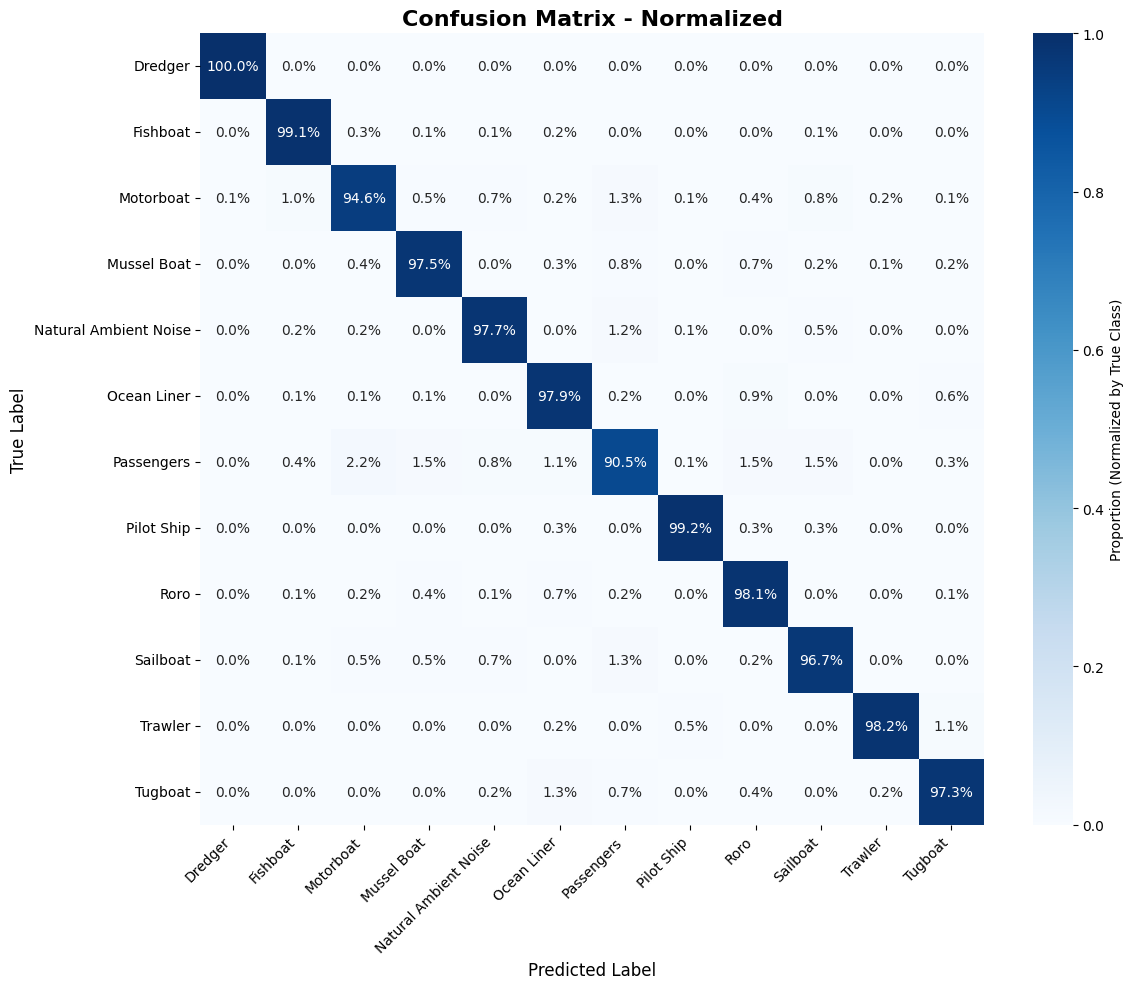

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Define the Class Names
class_names = [
    'Dredger', 'Fishboat', 'Motorboat', 'Mussel Boat',
    'Natural Ambient Noise', 'Ocean Liner', 'Passengers',
    'Pilot Ship', 'Roro', 'Sailboat', 'Trawler', 'Tugboat'
]

# 2. Reconstruct the Matrix manually from your 94.89% screenshot
# (I transcribed these values directly from your uploaded image)
cm_manual = np.array([
    [703,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0], # Dredger
    [  0, 1366,    4,    2,    1,    3,    0,    0,    0,    2,    0,    0], # Fishboat
    [  2,   26, 2574,   14,   18,    5,   36,    3,   10,   22,    6,    4], # Motorboat
    [  0,    0,    7, 1900,    0,    5,   15,    0,   13,    3,    1,    4], # Mussel Boat
    [  1,    6,    5,    0, 2988,    0,   37,    3,    1,   16,    0,    0], # Natural Ambient
    [  0,    3,    2,    3,    0, 2470,    6,    0,   23,    0,    1,   16], # Ocean Liner
    [  3,   42,  255,  171,   96,  123,10331,    9,  172,  170,    4,   34], # Passengers
    [  0,    0,    0,    0,    0,    1,    0,  366,    1,    1,    0,    0], # Pilot Ship
    [  1,    3,    9,   18,    3,   29,    7,    1, 3964,    0,    1,    4], # Roro
    [  0,    1,    6,    5,    8,    0,   14,    0,    2, 1055,    0,    0], # Sailboat
    [  0,    0,    0,    0,    0,    1,    0,    2,    0,    0,  429,    5], # Trawler
    [  0,    0,    0,    0,    1,    7,    4,    0,    2,    0,    1,  536]  # Tugboat
])

# 3. Normalize to get Percentages
# Divide each value by the sum of its row (True count)
cm_pct = cm_manual.astype('float') / (cm_manual.sum(axis=1)[:, np.newaxis] + 1e-10)

# 4. Plot Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(
    cm_pct,
    annot=True,
    fmt='.1%',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    cbar_kws={'label': 'Proportion (Normalized by True Class)'},
    vmin=0, vmax=1
)

plt.title('Confusion Matrix - Normalized', fontsize=16, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

# Save the plot
save_path = '/content/drive/MyDrive/shipsear_audio_temp/processed_data_DWSTr/confusion_matrix_pct_recovered.png'
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"✅ Recovered percentage plot saved to: {save_path}")
plt.show()

In [10]:
!jupyter nbconvert --ClearMetadataPreprocessor.enabled=True --to notebook --inplace your_notebook.ipynb


[NbConvertApp] WARNING | pattern 'your_notebook.ipynb' matched no files
This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--JupyterApp.generate_config=True]
-y
    Answer yes to any questions instead of prompting.
    Equivalent to: [--JupyterApp.answer_yes=True]
--execute
 